# AI4I 2020 PREDICTIVE MAINTENANCE IN INDUSTRY : CLASSIFICATION MACHINE LEARNING MODEL

###            NAME : Kanmani A

###            DATE: 08.07.2025

##              OVERVIEW OF PROBLEM STATMENT

In modern manufacturing industries, machinery forms the backbone of production processes.Industrial machines are the most important assets in manufacturing and production of the industry and bussiness.Unexpected machine failures can lead to costly downtime, reduced productivity, and safety risks.Usually, maintenance like fixing after failure and scheduled sevicing are often inefficient which can  be either too late or too frequent.Corrective maintenance often leads to costly downtime whereas preventive maintenance may cause unnecessary part replacements and resource wastage.

## Objectives

 Developing a machine learning models that can accurately predict whether a machine will fail (binary classification).By extending the analysis to identify which type of failure will occur.This demonstrates how predictive maintenance can reduce unplanned downtime and optimize maintenance schedules.It provides feature importance insights to highlight the key drivers of failures.In industrial settings, it is important not only to predict a failure but also to explain the contributing factors (e.g., torque, temperature) which is being analysed here.

### Data Description

**Source**: From UCI ML Repository, **link**:https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

### Features:

- **UDI (Unique ID)** - A unique identifier for each record.
- **Product ID** - Identifier of the product.
- **Type**  Same as Product ID, often used as categorical input in ML.
- **Air temperature [K]**- The surrounding environmental temperature in Kelvin.Baseline ~300 K (around 27°C).
- **Process temperature [K]**-The machine’s internal process temperature.Slightly higher than air temperature (air + ~10K + noise).
- **Rotational speed [rpm]**-Machine’s rotation per minute.
- **Torque [Nm]** -Torque applied to the machine (Newton meters).
- **Tool wear [min]** Time in minutes that the tool has been used.

   **Machine failure** - 1 = Failure occurred, 0 = No failure

- **TWF** -	Tool wear failure
- **HDF** -	Heat dissipation failure
- **PWF** -	Power failure
- **OSF** -	Overstrain failure
- **RNF** -	Random failure

## Importing library files

In [1]:
#importing all essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import PowerTransformer,LabelEncoder,OneHotEncoder,StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest ,mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, precision_score,f1_score,recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

### Data Collection

#### Loading the DataSet

In [2]:
data =pd.read_csv('industry.csv')

In [3]:
data

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


#### Converting data into DataFrame

In [4]:
df=pd.DataFrame(data)

In [5]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [6]:
df.head(10) #pass first 10 values

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [7]:
df.tail(10) # details of last 10 rows

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9990,9991,L57170,L,298.8,308.5,1527,36.2,3,0,0,0,0,0,0
9991,9992,M24851,M,298.9,308.4,1827,26.1,5,0,0,0,0,0,0
9992,9993,L57172,L,298.8,308.4,1484,39.2,8,0,0,0,0,0,0
9993,9994,L57173,L,298.8,308.4,1401,47.3,10,0,0,0,0,0,0
9994,9995,L57174,L,298.8,308.3,1634,27.9,12,0,0,0,0,0,0
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


#### Checking the shape of the DataFrame

In [8]:
df.shape

(10000, 14)

#### Displaying Columns

In [9]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

#### Displaying Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [11]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


#### Checking Datatypes

In [12]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [13]:
print(df['Machine failure'].dtype)

int64


## Data Cleaning and Preprocessing

#### Checking for Duplicates

In [14]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [15]:
df.duplicated().sum()

np.int64(0)

**No duplicate values found in the Dataset**

### Finding and Handling null values

In [16]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

**No Null values found in the dataset**

In [17]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

### Renaming Column names

In [18]:
df=df.rename(columns={'Air temperature [K]': 'Air Temperature',
                      'Process temperature [K]':'Process Temperature',
                      'Rotational speed [rpm]':'Rotational Speed',
                      'Torque [Nm]':'Torque',
                      'Tool wear [min]':'Tool Wear'})

In [19]:
df=df.rename(columns={'TWF': 'Toolwear Failure',
                      'HDF':'Heat Dissipation Failure',
                      'PWF':'Power Failure',
                      'OSF':'Overstrain Failure',
                      'RNF':'Random Failure'})

#### Checking the Renamed columns

In [20]:
df.head()

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [21]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air Temperature', 'Process Temperature',
       'Rotational Speed', 'Torque', 'Tool Wear', 'Machine failure',
       'Toolwear Failure', 'Heat Dissipation Failure', 'Power Failure',
       'Overstrain Failure', 'Random Failure'],
      dtype='object')

#### Replacing numerical values with actual labels

In [22]:
df.replace({'Machine failure':{1:'true',0:'false'}},inplace=True)

#### Checking the replaced values

In [23]:
df

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,false,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,false,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,false,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,false,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,false,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,false,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,false,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,false,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,false,0,0,0,0,0


**Counting y variable**

In [24]:
target_value=df['Machine failure'].value_counts()

In [25]:
target_value

Machine failure
false    9661
true      339
Name: count, dtype: int64

#### Finding unique values in a particular column

In [26]:
df['Type'].unique()

array(['M', 'L', 'H'], dtype=object)

#### Filtering the values of a column

In [27]:
filtered_df=df[df['Type']=='H']

In [28]:
filtered_df

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
10,11,H29424,H,298.4,308.9,1782,23.9,24,false,0,0,0,0,0
11,12,H29425,H,298.6,309.1,1423,44.3,29,false,0,0,0,0,0
18,19,H29432,H,298.8,309.2,1306,54.5,50,false,0,0,0,0,0
20,21,H29434,H,298.9,309.3,1375,42.7,58,false,0,0,0,0,0
27,28,H29441,H,299.1,309.4,1811,24.6,77,false,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9978,9979,H39392,H,298.6,308.3,1377,52.1,181,false,0,0,0,0,0
9984,9985,H39398,H,298.7,308.4,1432,42.8,197,false,0,0,0,0,0
9985,9986,H39399,H,298.7,308.5,1572,35.6,202,false,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,false,0,0,0,0,0


#### Sorting

In [29]:
sort_s=df.sort_values(by='Tool Wear')

In [30]:
sort_s

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
6341,6342,M21201,M,300.4,309.8,1421,47.2,0,false,0,0,0,0,0
8358,8359,L55538,L,298.7,309.7,1547,37.4,0,false,0,0,0,0,0
593,594,L47773,L,297.5,309.6,1312,50.7,0,false,0,0,0,0,0
6257,6258,L53437,L,301.1,310.7,1376,49.1,0,false,0,0,0,0,0
7427,7428,L54607,L,300.0,311.4,1634,31.9,0,false,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,5400,H34813,H,302.8,312.4,1411,53.8,246,true,0,0,0,1,0
2864,2865,H32278,H,300.6,309.4,1380,47.6,246,true,1,0,0,0,0
9671,9672,L56851,L,299.0,310.2,1412,44.1,246,false,0,0,0,0,0
5400,5401,L52580,L,302.7,312.4,1477,46.3,251,true,0,0,0,1,0


#### Grouping and finding the mean value

In [31]:
grouped_df=df.groupby('Type')['Tool Wear'].mean()

In [32]:
grouped_df

Type
H    107.419741
L    108.378833
M    107.272272
Name: Tool Wear, dtype: float64

### Statistical Analysis

In [33]:
mean_speed=df['Rotational Speed'].mean()
mean_speed

np.float64(1538.7761)

In [34]:
median_speed=df['Rotational Speed'].median()
median_speed

np.float64(1503.0)

In [35]:
std_speed=df['Rotational Speed'].std()
std_speed

np.float64(179.2840959134266)

## Dataset is imbalanced and EDA is required

### EDA - Exploratory Data Analysis (EDA)

#### Performing KDE Plots

In [36]:
#creating list of columns having continues numbers
continues_numerical_col =  [
    'Air Temperature', 'Process Temperature', 'Rotational Speed', 'Torque', 
    'Tool Wear'
]

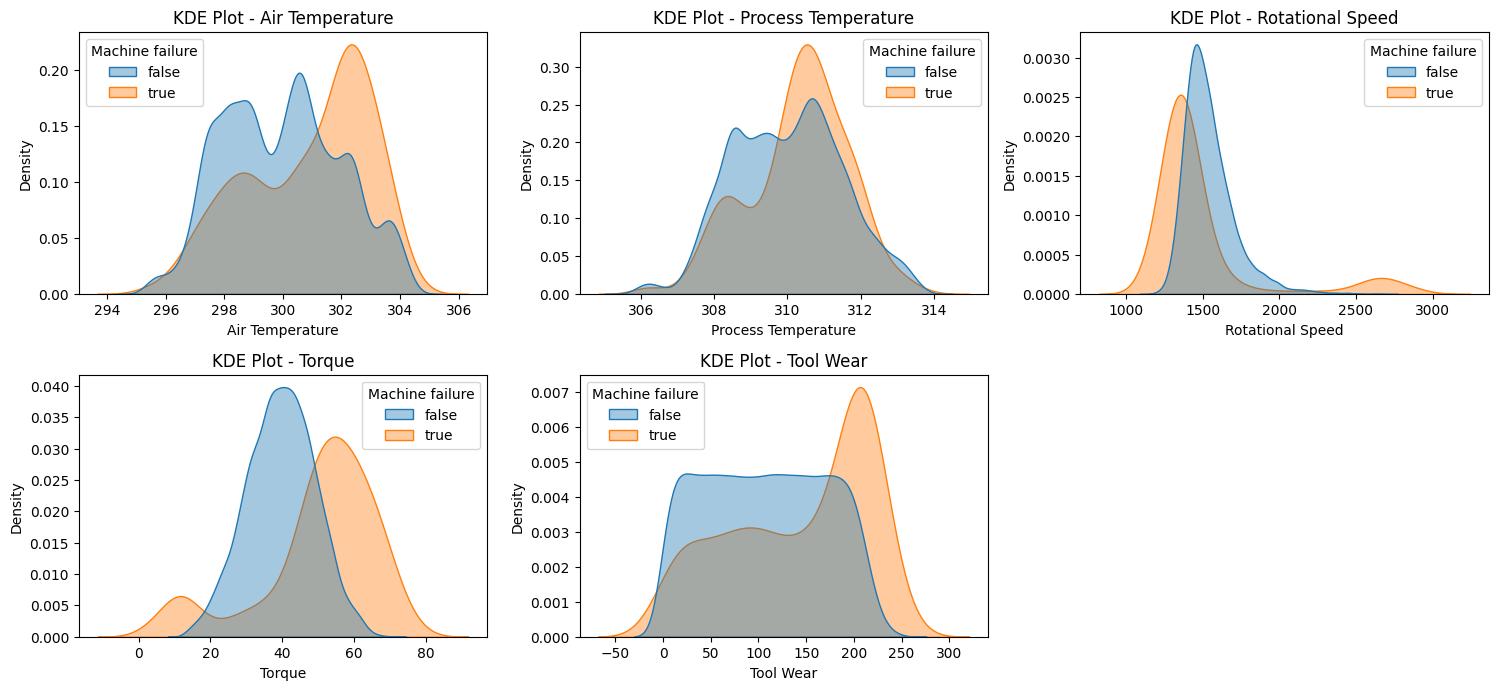

In [37]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(continues_numerical_col, 1):
    plt.subplot(3, 3, i)  # adjust rows/cols as needed
    sns.kdeplot(data=df, x=col, hue='Machine failure', fill=True, common_norm=False, alpha=0.4)
    plt.title(f"KDE Plot - {col}")
plt.tight_layout()
plt.show()

**From the above plot it is shown that Tool wear vs Machine failure in which failures cluster at higher tool wear values.**
**For Torque, the failure machines have higher/lower torque distributions than normal ones.**

In [38]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air Temperature', 'Process Temperature',
       'Rotational Speed', 'Torque', 'Tool Wear', 'Machine failure',
       'Toolwear Failure', 'Heat Dissipation Failure', 'Power Failure',
       'Overstrain Failure', 'Random Failure'],
      dtype='object')

#### Count Plot for status of failures

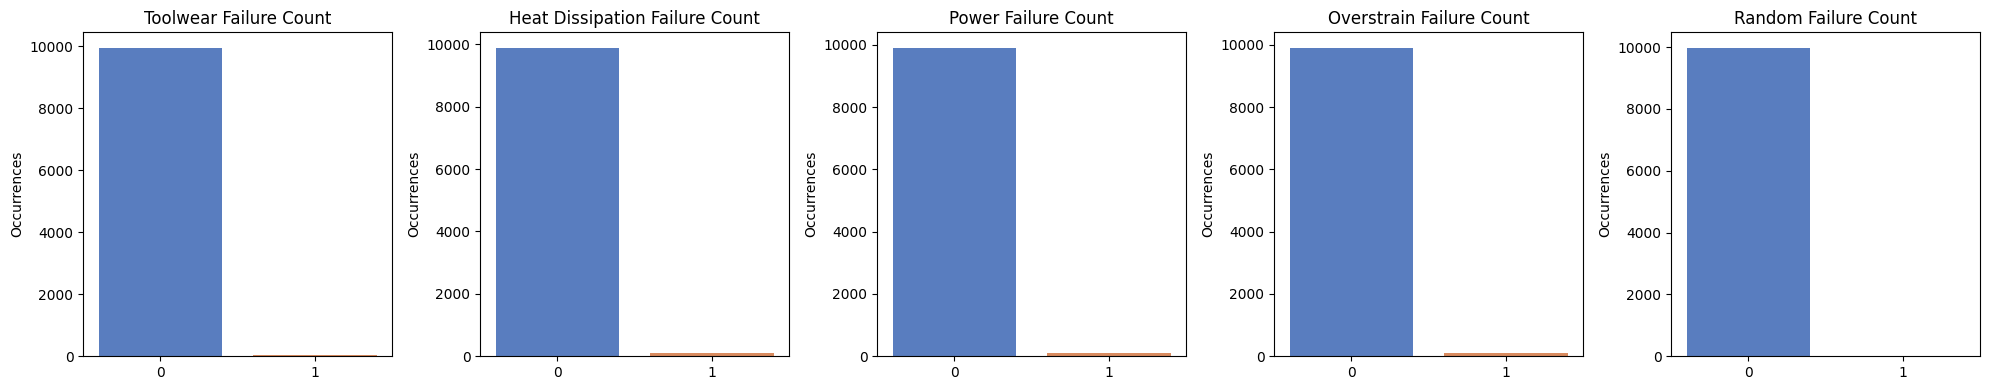

In [39]:
failure_modes = ['Toolwear Failure', 'Heat Dissipation Failure', 'Power Failure', 'Overstrain Failure', 'Random Failure']
fig, axes = plt.subplots(1, len(failure_modes), figsize=(20,4))

for ax, mode in zip(axes, failure_modes):
    sns.countplot(x=mode, data=df, ax=ax, palette='muted')
    ax.set_title(f'{mode} Count')
    ax.set_xlabel('')
    ax.set_ylabel('Occurrences')

plt.tight_layout()
plt.show()

- **From the above plots you can see and analyse which failure types are most prevalent**
- **It Reveals which specific failure types occur most frequent**

In [40]:
Product_varient= df['Type'].value_counts()
print("The Product_varient Types:")
print(Product_varient)

The Product_varient Types:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


#### Depend variable - 'Machine failure'

In [41]:
#Value counts
df['Machine failure'].value_counts()

Machine failure
false    9661
true      339
Name: count, dtype: int64

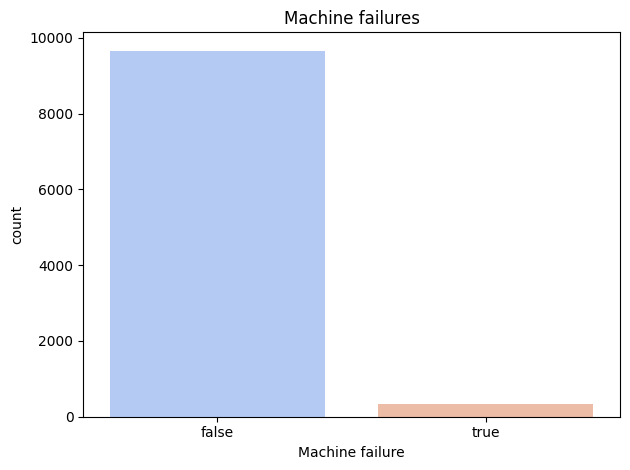

In [42]:
sns.countplot(x ='Machine failure', data = df, palette='coolwarm')
plt.title('Machine failures')
plt.tight_layout()  
plt.show()

**Independend Variables - Toolwear Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, Random Failure**
**Machine runs without failure is high here.**

#### Toolwear Failure

In [43]:
#Value counts for Toolwear Failure
df['Toolwear Failure'].value_counts()

Toolwear Failure
0    9954
1      46
Name: count, dtype: int64

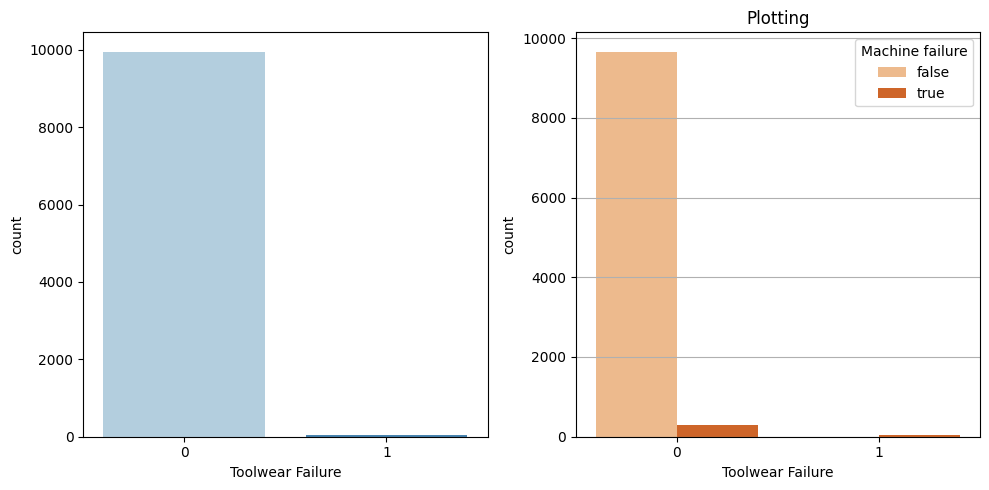

In [44]:
#count plot for Toolwear Failure with respect to Target
fig, axes = plt.subplots(ncols=2,figsize=(10,5))                                                           # 2 plots side by side
plt.title('Plotting')
sns.countplot(x = 'Toolwear Failure', ax = axes[0], data = df, palette = 'Blues')                          # Toolwear Failure counts
sns.countplot(x = 'Toolwear Failure', hue = 'Machine failure',ax = axes[1], data = df, palette ='Oranges') #Toolwear Failure split by Machine Failure
plt.grid(axis='y')                                                                                         # Grid lines only for y-axis
plt.tight_layout()
plt.show()

**Distribution of Toolwear Failure (0 = No failure, 1 = Failure).
Stacked distribution for each Toolwear Failure status, it shows how many had Machine failure = 0 vs Machine failure = 1.
This checks if Toolwear Failure strongly overlaps with Machine Failure.**

#### Heat Dissipation Failure

In [45]:
#Value counts for Heat Dissipation Failure
df['Heat Dissipation Failure'].value_counts()

Heat Dissipation Failure
0    9885
1     115
Name: count, dtype: int64

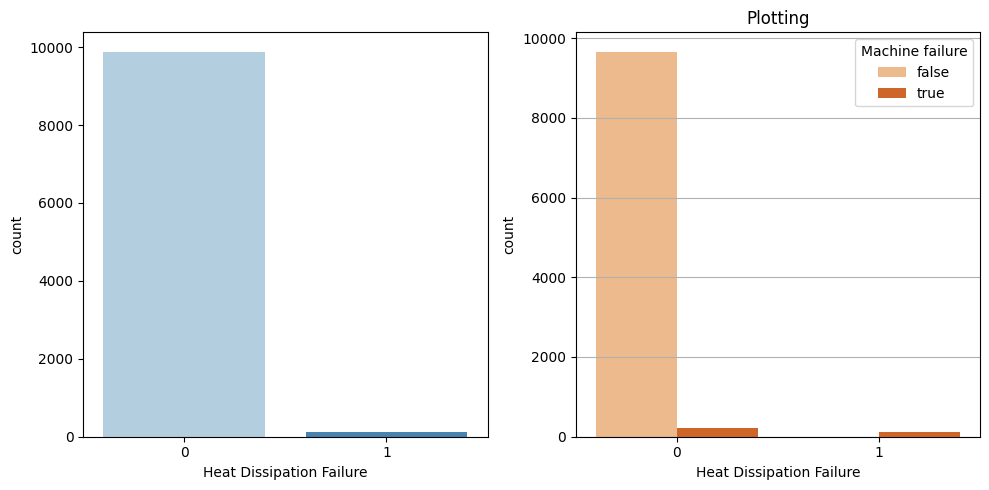

In [46]:
#count plot for Heat Dissipation Failure with respect to Target
fig, axes = plt.subplots(ncols=2,figsize=(10,5))
plt.title('Plotting')
sns.countplot(x = 'Heat Dissipation Failure', ax = axes[0], data = df, palette = 'Blues')
sns.countplot(x = 'Heat Dissipation Failure', hue = 'Machine failure',ax = axes[1], data = df, palette ='Oranges')
# Grid lines only for y-axis
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Air Temperature

#### Count Plot for Air Temperature with respect to Failure

In [47]:
df['Air Temperature'].value_counts()

Air Temperature
300.7    279
298.9    231
297.4    230
300.5    229
298.8    227
        ... 
304.4      7
296.0      6
295.3      3
295.4      3
304.5      1
Name: count, Length: 93, dtype: int64

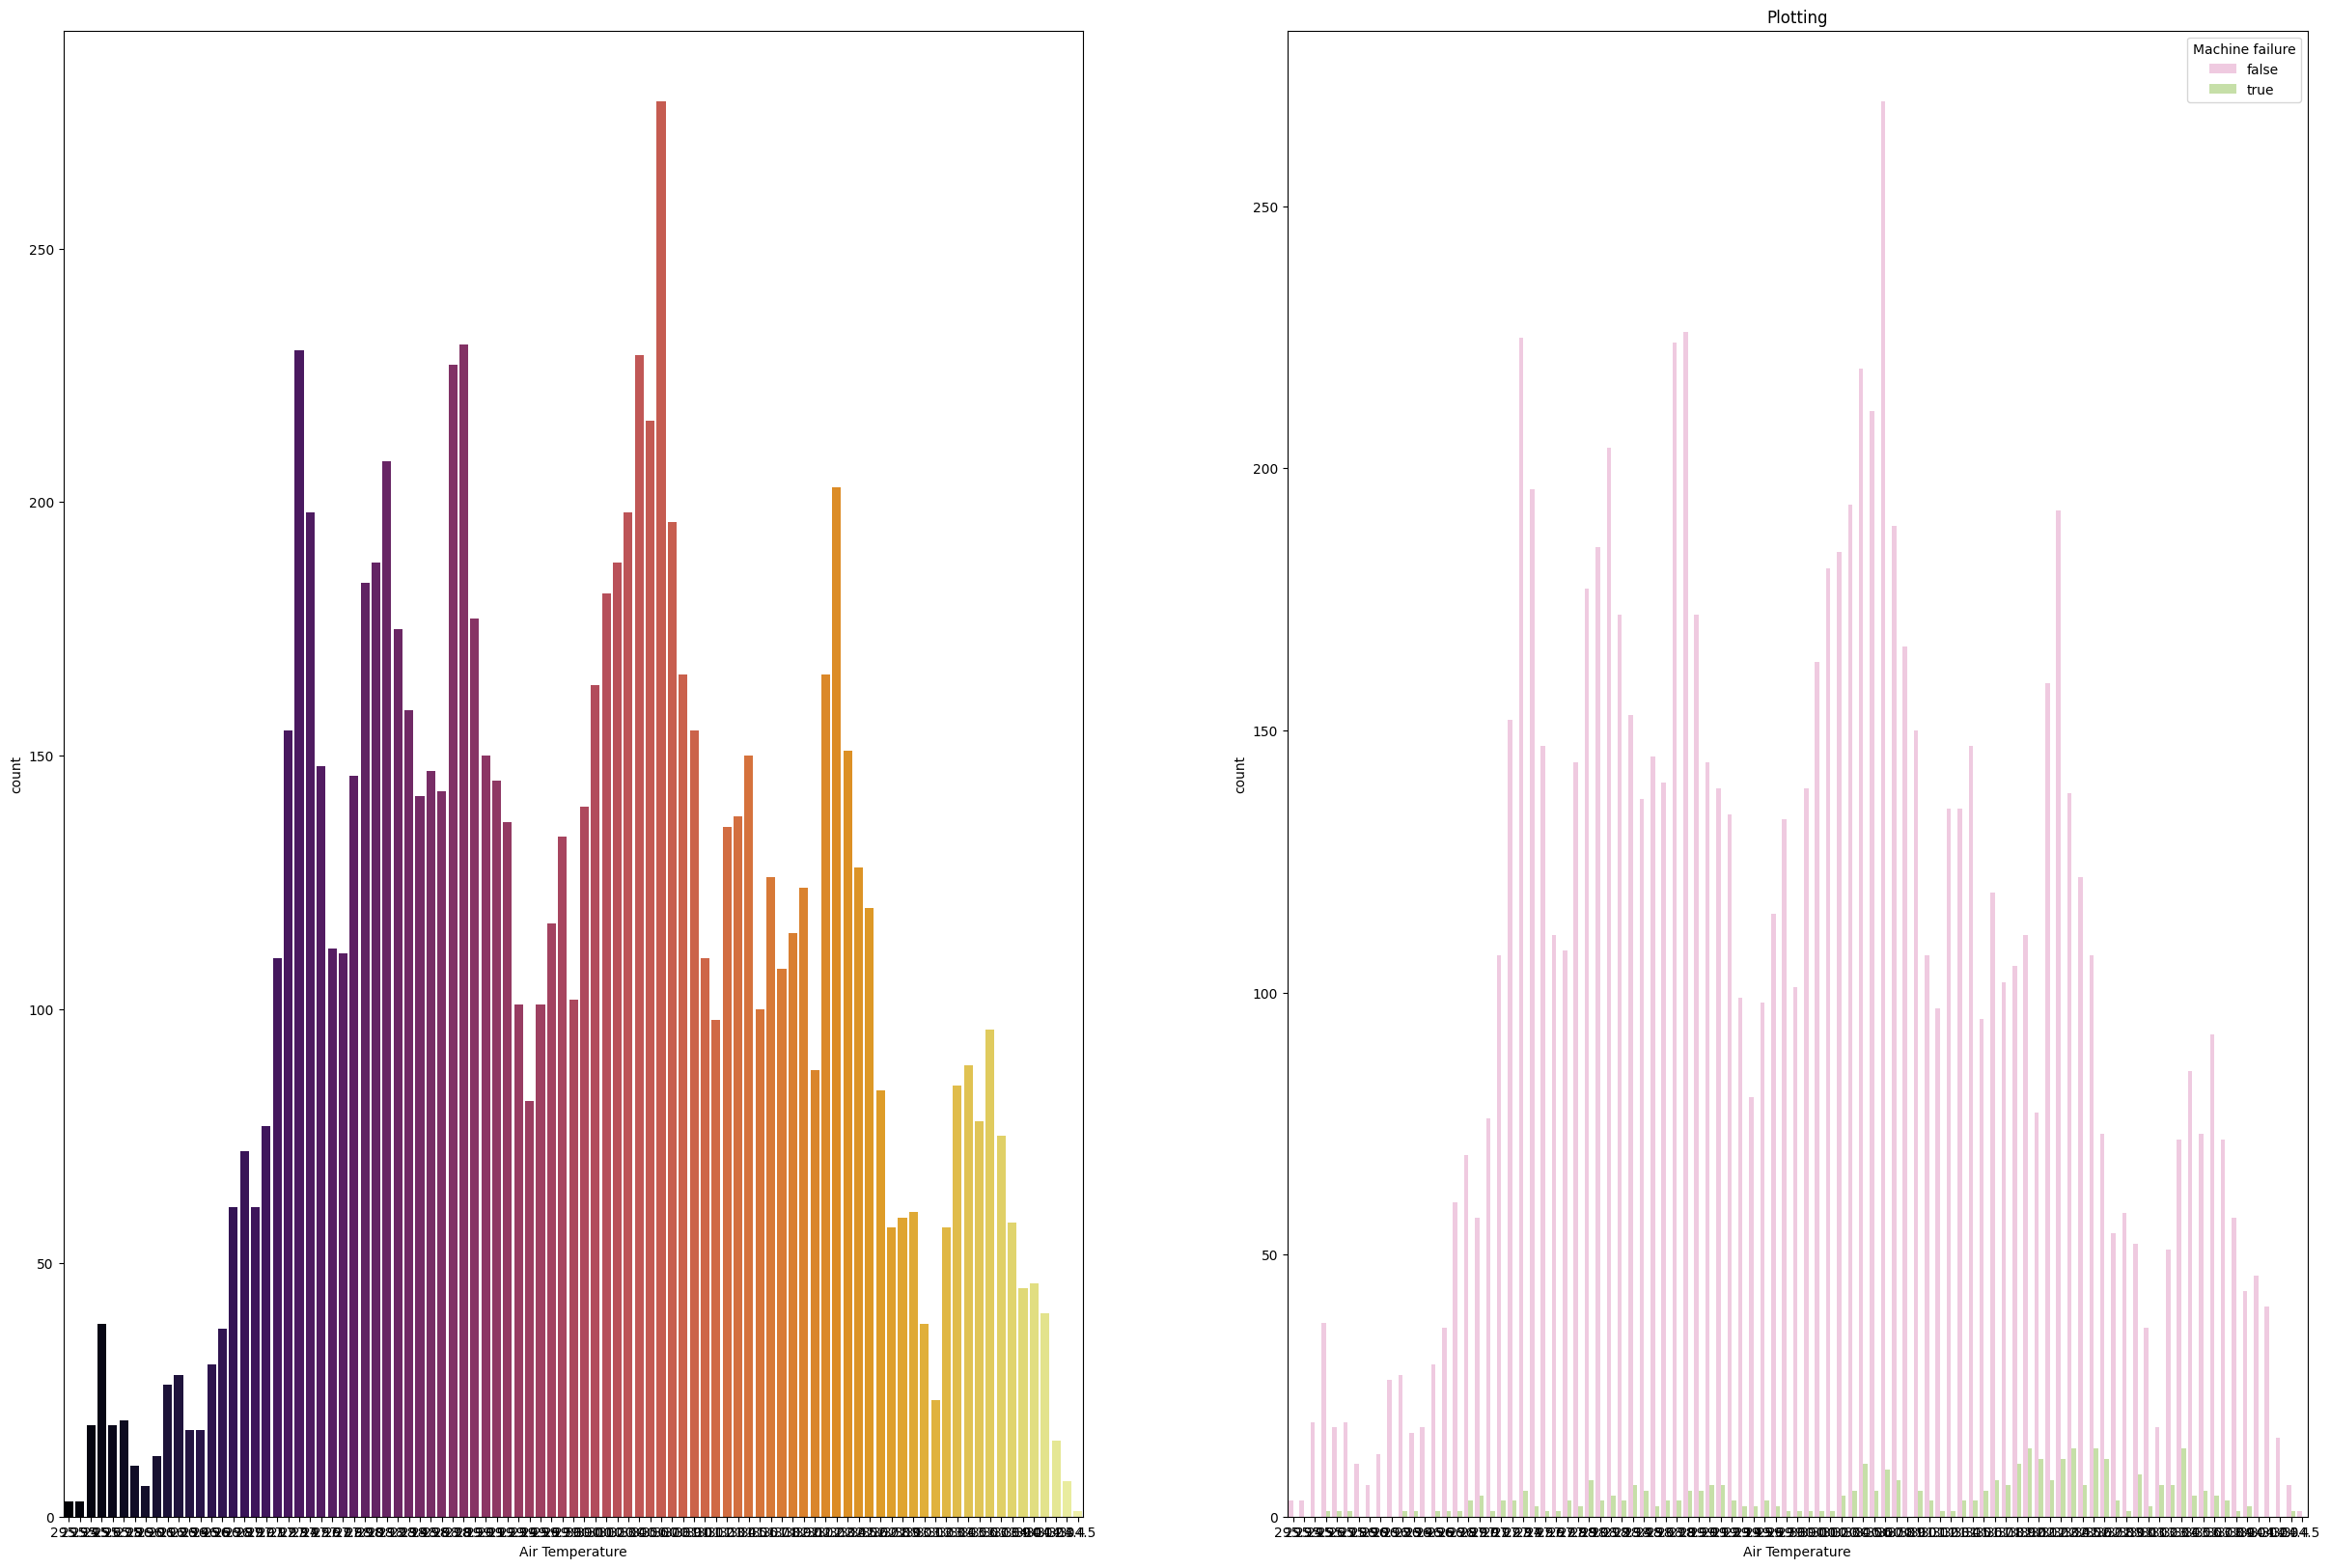

In [48]:
#Count plot for  with respect to Target
fig, axes = plt.subplots(ncols=2,figsize=(30,20))
plt.title('Plotting')
sns.countplot(x = 'Air Temperature',ax = axes[0], data = df, palette = 'inferno')
sns.countplot(x = 'Air Temperature', hue = 'Machine failure', data = df,ax = axes[1], palette = 'PiYG')
plt.show()

In [49]:
df

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,false,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,false,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,false,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,false,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,false,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,false,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,false,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,false,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,false,0,0,0,0,0


#### Plotting Tool wear with respect to Temperature defference by Machine failure

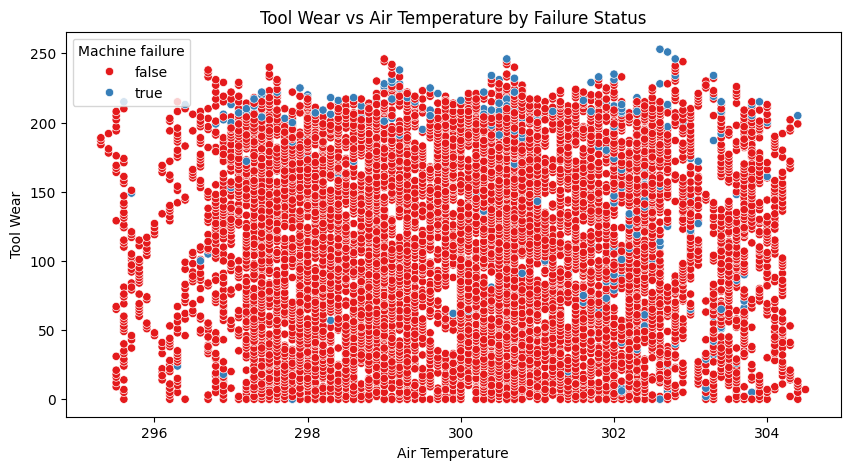

In [50]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Air Temperature', y='Tool Wear',
                hue='Machine failure', data=df, palette='Set1')
plt.title('Tool Wear vs Air Temperature by Failure Status')
plt.xlabel('Air Temperature')
plt.ylabel('Tool Wear')
plt.show()

#### Pie chart for Failure modes

In [51]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air Temperature', 'Process Temperature',
       'Rotational Speed', 'Torque', 'Tool Wear', 'Machine failure',
       'Toolwear Failure', 'Heat Dissipation Failure', 'Power Failure',
       'Overstrain Failure', 'Random Failure'],
      dtype='object')

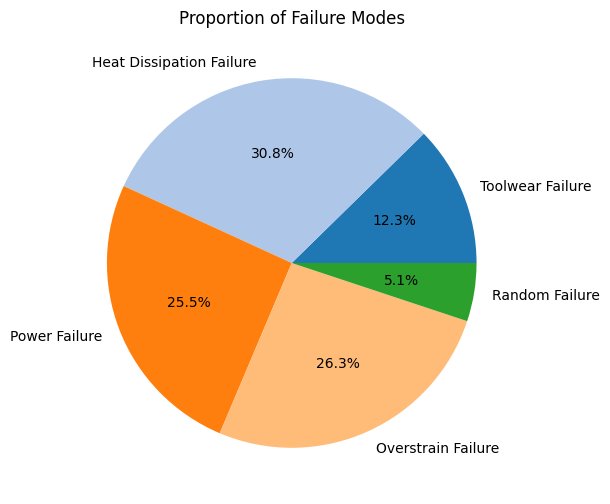

In [52]:
# Pie Chart: Distribution of Failure Modes
failure_counts = {
    'Toolwear Failure': df['Toolwear Failure'].sum(),
    'Heat Dissipation Failure': df['Heat Dissipation Failure'].sum(),
    'Power Failure': df['Power Failure'].sum(),
    'Overstrain Failure': df['Overstrain Failure'].sum(),
    'Random Failure': df['Random Failure'].sum()
}
plt.figure(figsize=(6,6))
plt.pie(failure_counts.values(),
        labels=failure_counts.keys(),
        autopct='%1.1f%%',
        colors=plt.cm.tab20.colors)
plt.title('Proportion of Failure Modes')
plt.show()


**Toolwear Failure dominating the chart, with the others having much smaller size.**

#### Removing Outliers

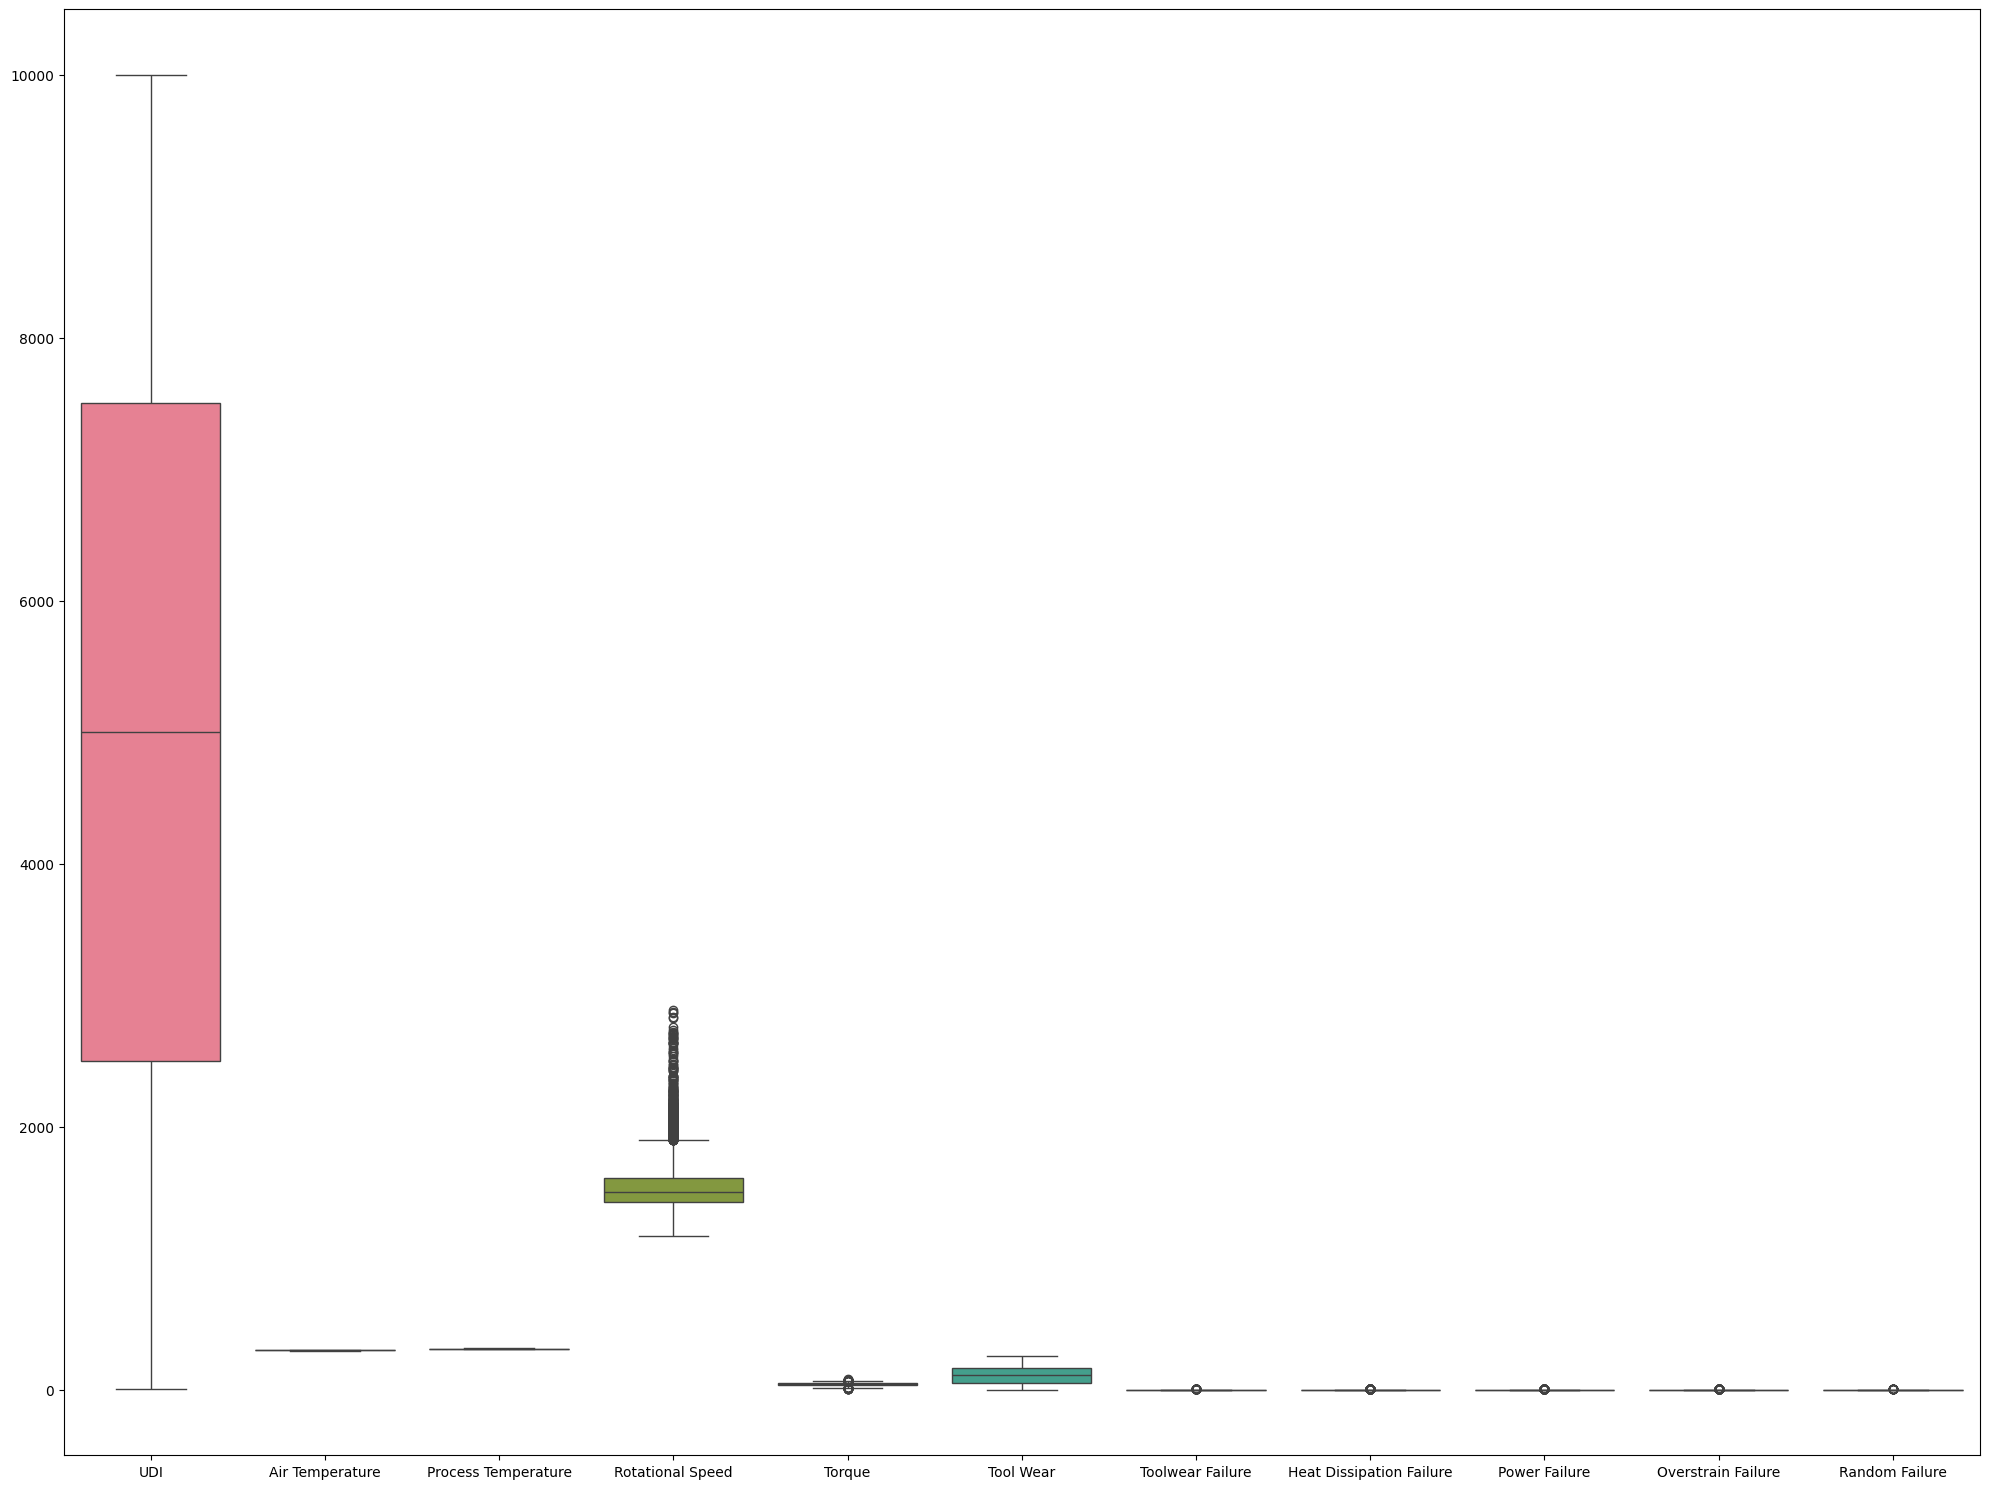

In [53]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df)
plt.tight_layout()
plt.show()

#### Handling Outliers by using IQR

In [54]:
def fix_outliers_iqr(df):                                        # Function to apply IQR method to fix outliers
    num=df.select_dtypes(include='number').columns
    for col in num:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR                             # Replace outliers with the respective bounds
        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
    return df

In [55]:
df1=fix_outliers_iqr(df)
df1

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,false,0.0,0.0,0.0,0.0,0.0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,false,0.0,0.0,0.0,0.0,0.0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,false,0.0,0.0,0.0,0.0,0.0
3,4,L47183,L,298.2,308.6,1433.0,39.5,7,false,0.0,0.0,0.0,0.0,0.0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,false,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,false,0.0,0.0,0.0,0.0,0.0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,false,0.0,0.0,0.0,0.0,0.0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,false,0.0,0.0,0.0,0.0,0.0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,false,0.0,0.0,0.0,0.0,0.0


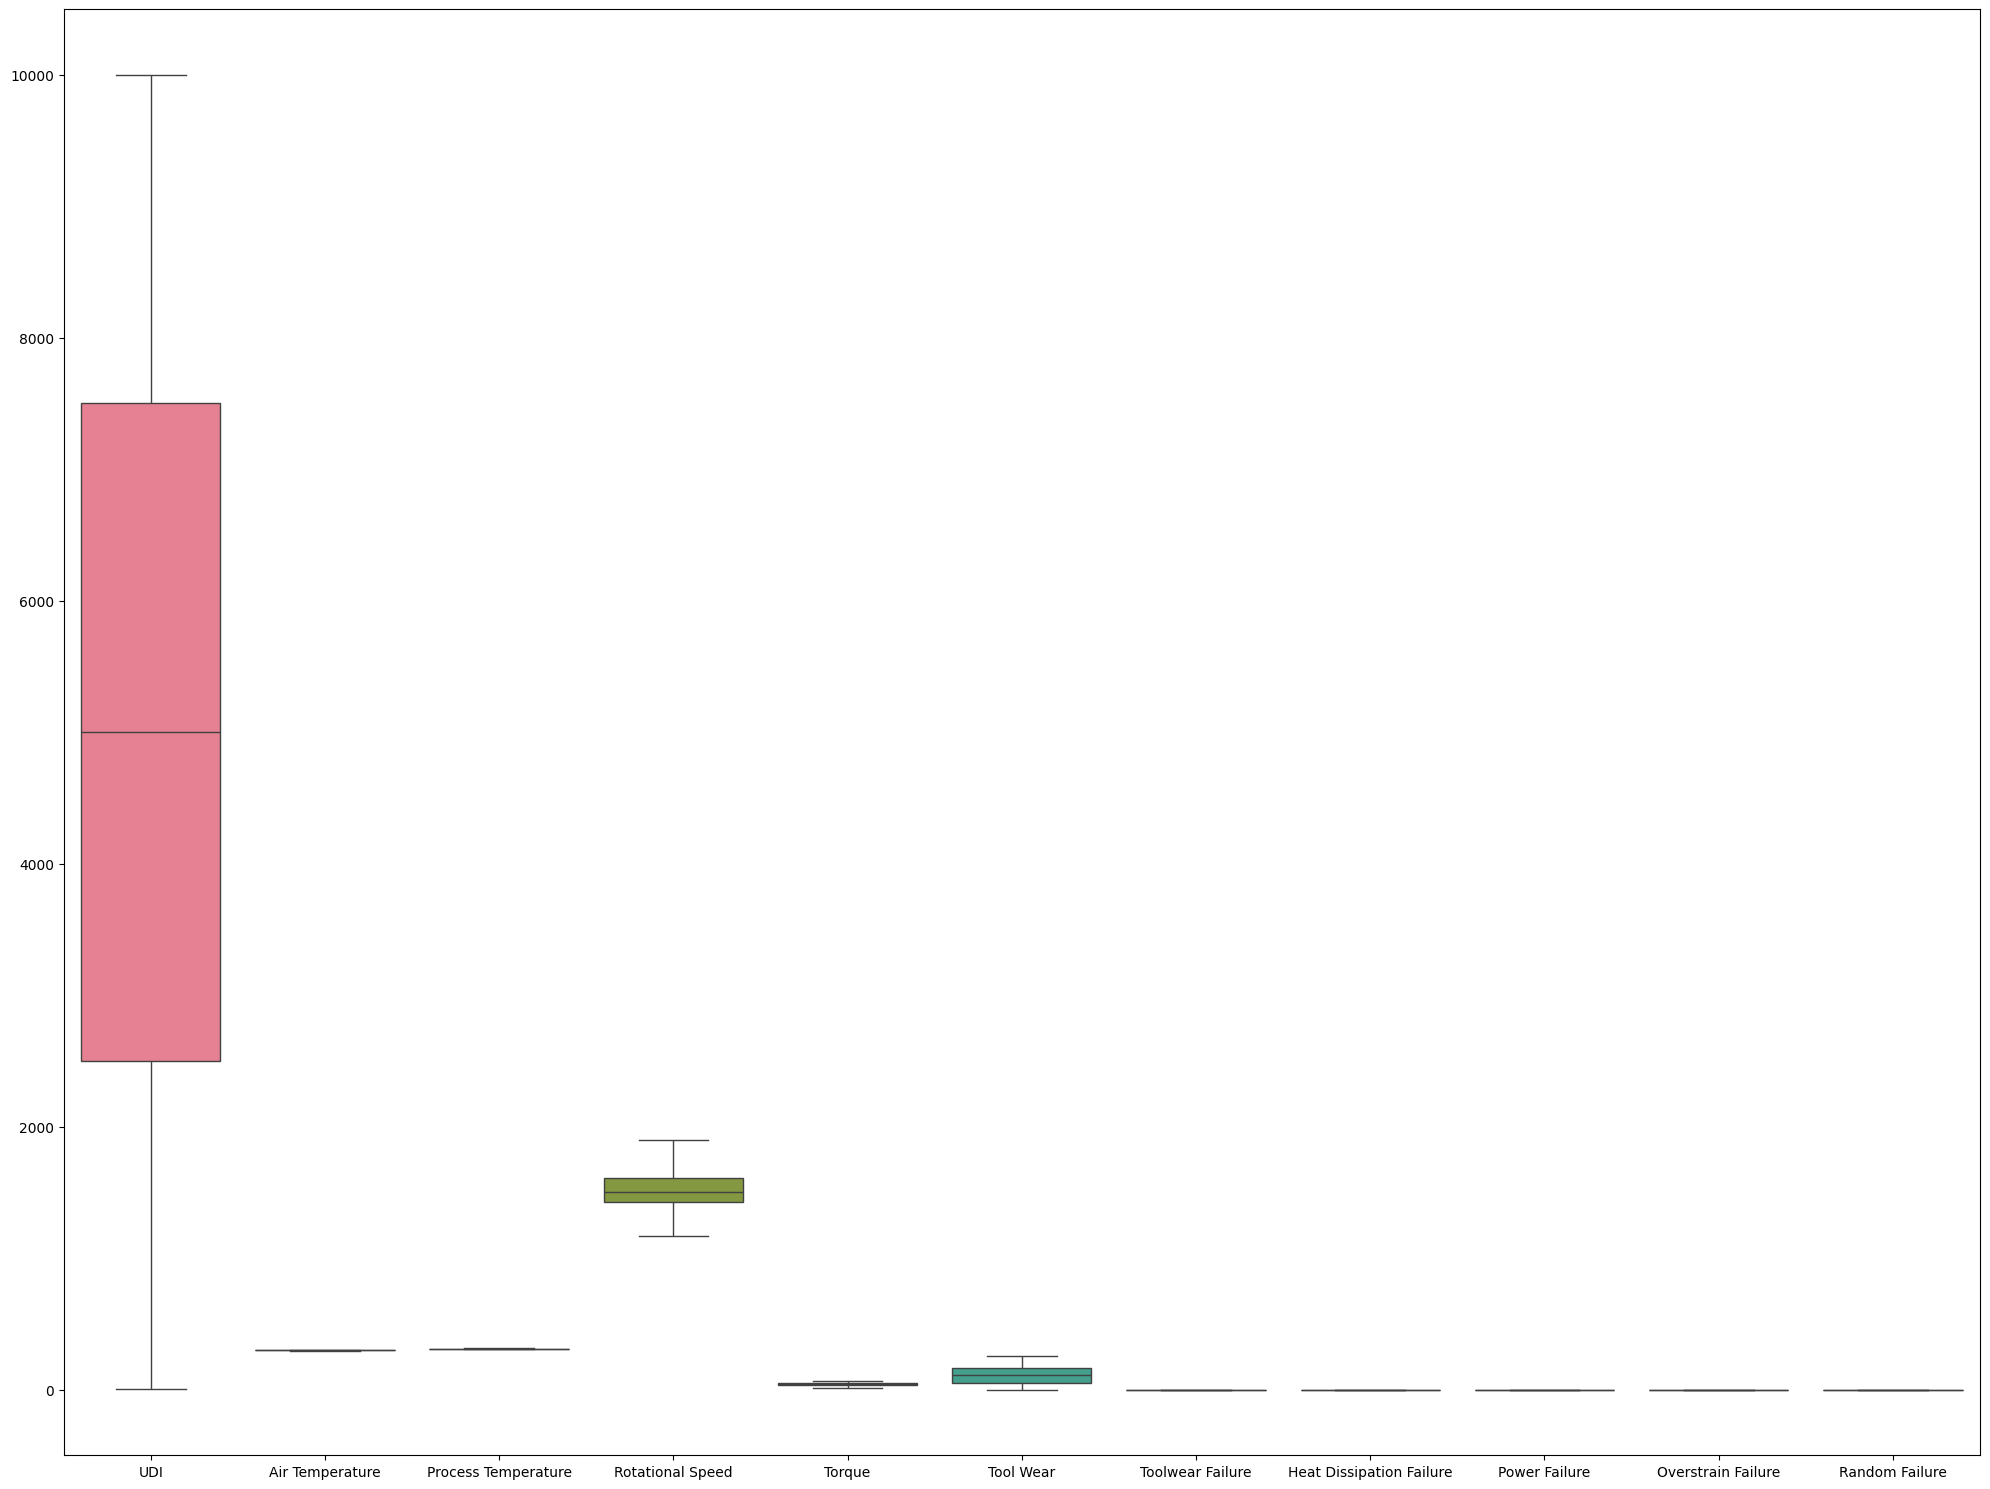

In [56]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df1)
plt.tight_layout()
plt.show()

### Correlation

In [57]:
df['Machine failure'].value_counts()

Machine failure
false    9661
true      339
Name: count, dtype: int64

In [58]:
df1['Machine failure'] = df1['Machine failure'].map({'true': 1, 'false': 0})
df1

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0.0,0.0,0.0,0.0,0.0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0.0,0.0,0.0,0.0,0.0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0.0,0.0,0.0,0.0,0.0
3,4,L47183,L,298.2,308.6,1433.0,39.5,7,0,0.0,0.0,0.0,0.0,0.0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0.0,0.0,0.0,0.0,0.0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0.0,0.0,0.0,0.0,0.0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0.0,0.0,0.0,0.0,0.0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0.0,0.0,0.0,0.0,0.0


In [59]:
cor = df1[[
    'Air Temperature', 'Process Temperature',
    'Rotational Speed', 'Torque', 'Tool Wear', 'Machine failure'
]].corr()
cor

,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure
Air Temperature,1.000000,0.876107,0.021305,-0.013861,0.013853,0.082556
Process Temperature,0.876107,1.000000,0.019892,-0.014294,0.013488,0.035946
Rotational Speed,0.021305,0.019892,1.000000,-0.911734,0.002496,-0.130467
Torque,-0.013861,-0.014294,-0.911734,1.000000,-0.003151,0.190806
Tool Wear,0.013853,0.013488,0.002496,-0.003151,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.130467,0.190806,0.105448,1.000000


In [60]:
cor['Machine failure'].sort_values(ascending=False)

Machine failure        1.000000
Torque                 0.190806
Tool Wear              0.105448
Air Temperature        0.082556
Process Temperature    0.035946
Rotational Speed      -0.130467
Name: Machine failure, dtype: float64

### Heatmap to show Correlation

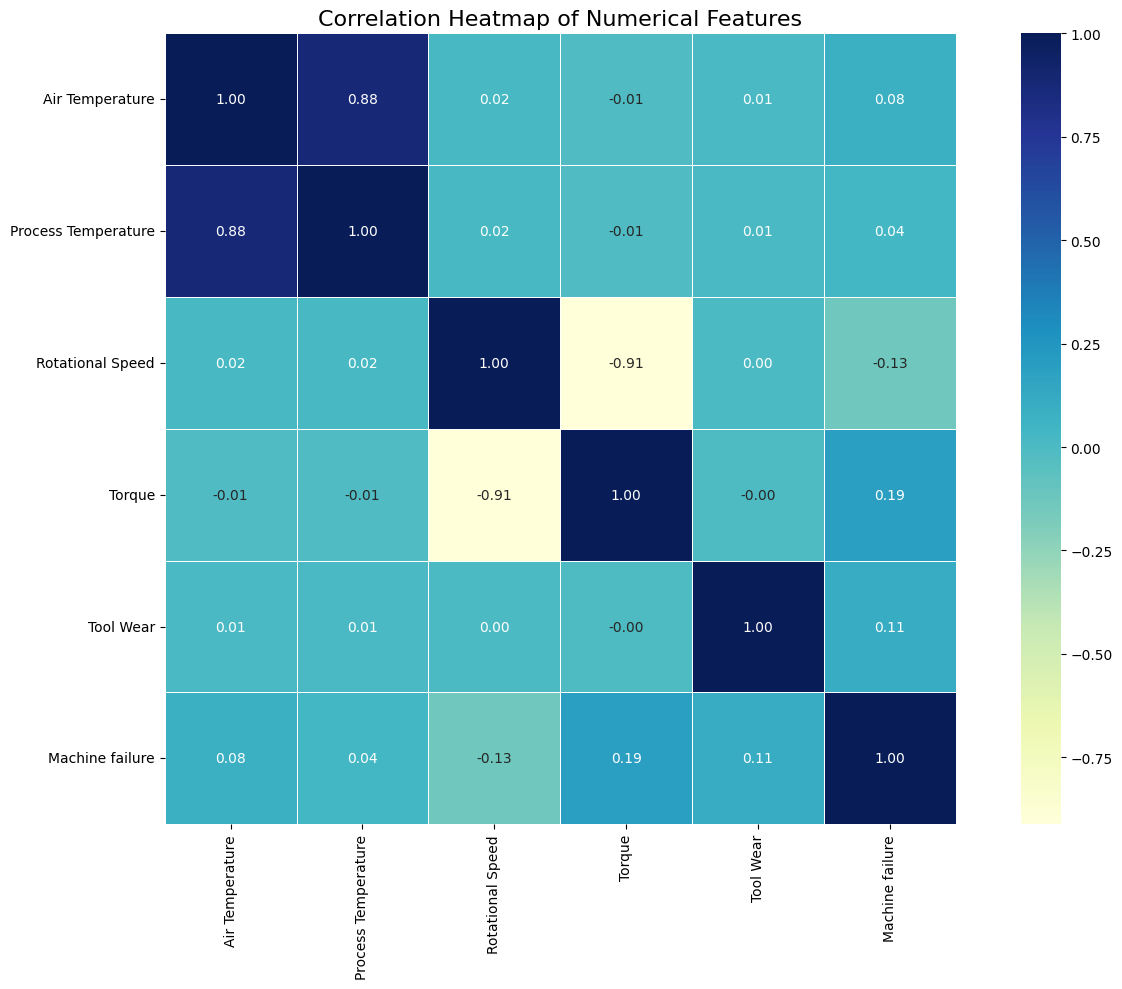

In [61]:
# Heatmap to show correlation
plt.figure(figsize=(14, 10))
sns.heatmap(cor, 
            annot=True, 
            fmt=".2f", 
            cmap='YlGnBu', 
            linewidths=0.5, 
            cbar=True,            #display the color bar on the side.
            square=True)
# Displaying the heatmap
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

- **Machine failure=(Tool Wear or Heat Dissipation Failure  or Power failure or Overstrain Failure or Random Failure)**
- **If we try to compute correlation between these, we will see an extremely high correlation (often close to 1).**
- **These columns aren’t really independent features,they are derived labels that directly describe why a failure happened.**

### Observations

- There is a strong feature-to-feature correlations (like between air and process temperature).
  
- The heatmap shows very weak overall correlations between individual numeric features and failures — meaning you’ll likely need non-linear models (e.g., Random Forest, XGBoost) to capture the interactions.

- Tool wear - Highest positive correlation with failures (machines fail more often as tools get older).

- Torque - Slight positive correlation (higher torque sometimes contributes to overstrain failures).

- Rotational speed - Slight negative correlation (some failure types happen at low RPM).

- Air temperature & Process temperature - Very low correlation with overall failures, because temperature-related failures (Heat Dissipation failure) are rare in the dataset.




### Skewness

In [62]:
df1= df1.select_dtypes(include='number')
df1

,UDI,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,298.1,308.6,1551.0,42.8,0,0,0.0,0.0,0.0,0.0,0.0
1,2,298.2,308.7,1408.0,46.3,3,0,0.0,0.0,0.0,0.0,0.0
2,3,298.1,308.5,1498.0,49.4,5,0,0.0,0.0,0.0,0.0,0.0
3,4,298.2,308.6,1433.0,39.5,7,0,0.0,0.0,0.0,0.0,0.0
4,5,298.2,308.7,1408.0,40.0,9,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,298.8,308.4,1604.0,29.5,14,0,0.0,0.0,0.0,0.0,0.0
9996,9997,298.9,308.4,1632.0,31.8,17,0,0.0,0.0,0.0,0.0,0.0
9997,9998,299.0,308.6,1645.0,33.4,22,0,0.0,0.0,0.0,0.0,0.0
9998,9999,299.0,308.7,1408.0,48.5,25,0,0.0,0.0,0.0,0.0,0.0


In [63]:
skew_values = df1[['Air Temperature', 'Process Temperature',
    'Rotational Speed', 'Torque', 'Tool Wear', ]].skew()
skew_values

Air Temperature        0.114274
Process Temperature    0.015027
Rotational Speed       0.746154
Torque                -0.017483
Tool Wear              0.027292
dtype: float64

#### Skewness by power transformer method

In [64]:
pt=PowerTransformer(method='yeo-johnson')
numeric_cols = ['Air Temperature', 'Process Temperature',
    'Rotational Speed', 'Torque', 'Tool Wear' ]

In [65]:
df_transformed = pd.DataFrame(
    pt.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

In [66]:
df_transformed.skew()

Air Temperature        0.000000
Process Temperature    0.000294
Rotational Speed       0.028783
Torque                -0.016626
Tool Wear             -0.285286
dtype: float64

#### Plotting Histogram

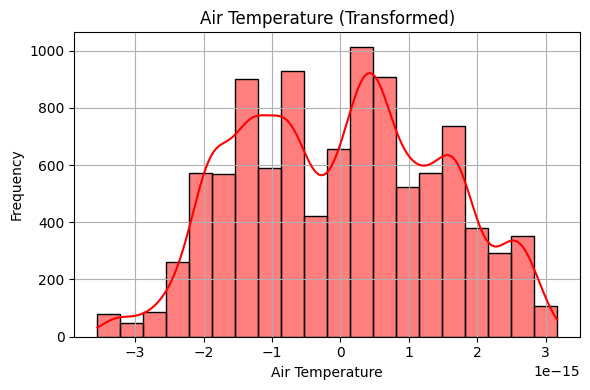

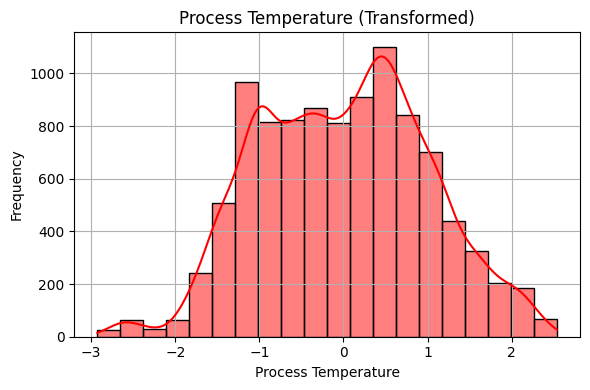

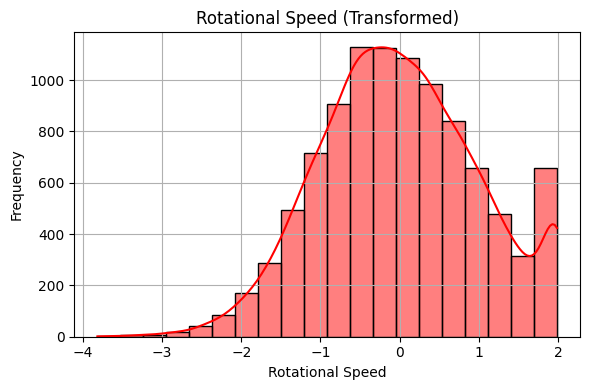

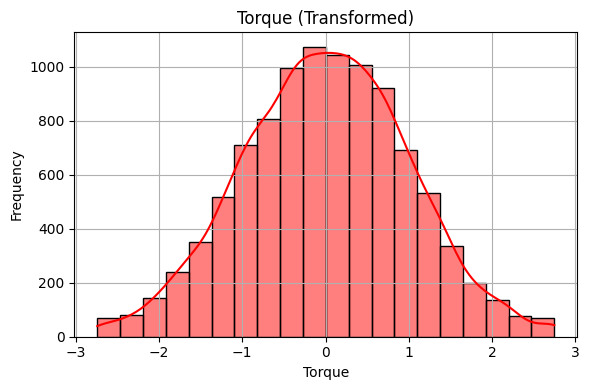

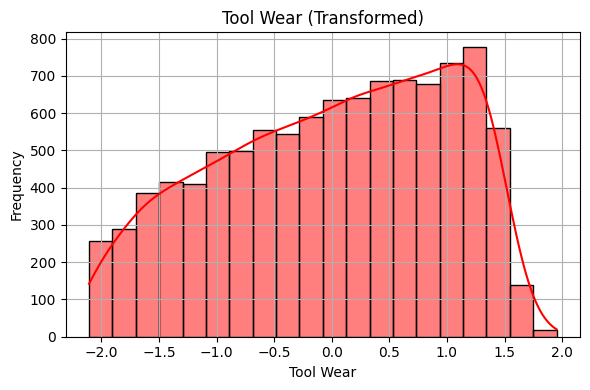

In [67]:
# Ploting the each column
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_transformed[col], kde=True, bins=20, color='red')
    plt.title(f"{col} (Transformed)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [68]:
df_transformed

,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear
0,-1.360023e-15,-0.947045,0.297402,0.283962,-2.106867
1,-1.304512e-15,-0.879238,-0.826894,0.637053,-1.964290
2,-1.360023e-15,-1.014882,-0.079306,0.949816,-1.889161
3,-1.304512e-15,-0.947045,-0.604015,-0.048920,-1.821417
4,-1.304512e-15,-0.879238,-0.826894,0.001515,-1.758683
...,...,...,...,...,...
9995,-8.604228e-16,-1.082748,0.634909,-1.057442,-1.616470
9996,-7.771561e-16,-1.082748,0.799187,-0.825514,-1.538206
9997,-6.938894e-16,-0.947045,0.872424,-0.664160,-1.416032
9998,-6.938894e-16,-0.879238,-0.826894,0.859012,-1.346640


### Feature Engineering

### Encoding

#### Label encoding

In [69]:
df_encoded = df.copy()
le = LabelEncoder()                                                # Encode 'Type'
df_encoded['Type'] = le.fit_transform(df['Type'])                 
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))  # If you want to see mapping
print("Label Encoding mapping:", label_mapping)

Label Encoding mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


In [70]:
df_encoded

,UDI,Product ID,Type,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,M14860,2,298.1,308.6,1551.0,42.8,0,0,0.0,0.0,0.0,0.0,0.0
1,2,L47181,1,298.2,308.7,1408.0,46.3,3,0,0.0,0.0,0.0,0.0,0.0
2,3,L47182,1,298.1,308.5,1498.0,49.4,5,0,0.0,0.0,0.0,0.0,0.0
3,4,L47183,1,298.2,308.6,1433.0,39.5,7,0,0.0,0.0,0.0,0.0,0.0
4,5,L47184,1,298.2,308.7,1408.0,40.0,9,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,2,298.8,308.4,1604.0,29.5,14,0,0.0,0.0,0.0,0.0,0.0
9996,9997,H39410,0,298.9,308.4,1632.0,31.8,17,0,0.0,0.0,0.0,0.0,0.0
9997,9998,M24857,2,299.0,308.6,1645.0,33.4,22,0,0.0,0.0,0.0,0.0,0.0
9998,9999,H39412,0,299.0,308.7,1408.0,48.5,25,0,0.0,0.0,0.0,0.0,0.0


#### Onehot encoding

In [71]:
ohe=OneHotEncoder(sparse_output=False,drop=None)          # Initialize OHE
typ = ohe.fit_transform(df[['Type']])                     # Fit + transform 'Type'
cols= ohe.get_feature_names_out(['Type'])                 # Extract new column names
df_encoded=pd.DataFrame(typ,columns=cols)                 # Build new DataFrame
df_encoded

,Type_H,Type_L,Type_M
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
9995,0.0,0.0,1.0
9996,1.0,0.0,0.0
9997,0.0,0.0,1.0
9998,1.0,0.0,0.0


In [72]:
df1=pd.concat([df.drop('Type',axis=1), df_encoded],axis=1)
df1= pd.DataFrame(df1)
df1

,UDI,Product ID,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Machine failure,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,Type_H,Type_L,Type_M
0,1,M14860,298.1,308.6,1551.0,42.8,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,L47181,298.2,308.7,1408.0,46.3,3,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,L47182,298.1,308.5,1498.0,49.4,5,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,L47183,298.2,308.6,1433.0,39.5,7,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,L47184,298.2,308.7,1408.0,40.0,9,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,298.8,308.4,1604.0,29.5,14,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9996,9997,H39410,298.9,308.4,1632.0,31.8,17,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9997,9998,M24857,299.0,308.6,1645.0,33.4,22,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9998,9999,H39412,299.0,308.7,1408.0,48.5,25,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [73]:
print('Length of Encoded clean data frame',len(df1))

Length of Encoded clean data frame 10000


In [74]:
df1.shape

(10000, 16)

### Handling Class Imbalance

**Since this data is imbalanced , using SMOTE (Synthetic Minority Oversampling Technique) to handle imbalance**

### SMOTE

In [75]:
# Using SMOTE
smote = SMOTE()

In [76]:
df1 = df1.drop(columns=['UDI', 'Product ID'])

In [77]:
x_smote, y_smote = smote.fit_resample(df1[(i for i in list(df1.describe(include='all').columns) if i != 'Machine failure')], df1['Machine failure'])

In [78]:
print('length of y smote',len(y_smote))

length of y smote 19322


In [79]:
balanced_df = pd.DataFrame(x_smote, columns=list(i for i in list(df1.describe(include='all').columns) if i != 'Machine failure'))

In [80]:
balanced_df

,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,Type_H,Type_L,Type_M
0,298.100000,308.600000,1551.000000,42.800000,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000
1,298.200000,308.700000,1408.000000,46.300000,3,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
2,298.100000,308.500000,1498.000000,49.400000,5,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
3,298.200000,308.600000,1433.000000,39.500000,7,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
4,298.200000,308.700000,1408.000000,40.000000,9,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19317,303.133923,311.357951,1324.060070,53.653365,226,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
19318,297.698695,307.586213,1243.574753,65.178808,89,0.0,0.0,0.0,0.0,0.0,0.000000,0.306241,0.693759
19319,301.001672,310.465552,1266.134331,62.790805,148,0.0,0.0,0.0,0.0,0.0,0.445373,0.554627,0.000000
19320,300.330452,311.246302,1504.212296,43.857252,215,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000


**Adding Machine Failure variable to newly created dataframe**

In [81]:
balanced_df['Machine failure'] = y_smote

In [82]:
balanced_df.shape

(19322, 14)

In [83]:
balanced_df['Machine failure'].value_counts()

Machine failure
0    9661
1    9661
Name: count, dtype: int64

In [84]:
balanced_df.to_csv("balanced dataset.csv",index=False)

## Feature Selection

In [85]:
skb= SelectKBest(score_func=mutual_info_classif,k=25)
y= balanced_df['Machine failure']
X= balanced_df.drop('Machine failure', axis=1)

In [86]:
X.columns

Index(['Air Temperature', 'Process Temperature', 'Rotational Speed', 'Torque',
       'Tool Wear', 'Toolwear Failure', 'Heat Dissipation Failure',
       'Power Failure', 'Overstrain Failure', 'Random Failure', 'Type_H',
       'Type_L', 'Type_M'],
      dtype='object')

In [87]:
y

0        0
1        0
2        0
3        0
4        0
        ..
19317    1
19318    1
19319    1
19320    1
19321    1
Name: Machine failure, Length: 19322, dtype: int64

In [88]:
X_new = skb.fit_transform(X , y)

In [89]:
selected_columns= X.columns[skb.get_support()]
selected_columns

Index(['Air Temperature', 'Process Temperature', 'Rotational Speed', 'Torque',
       'Tool Wear', 'Toolwear Failure', 'Heat Dissipation Failure',
       'Power Failure', 'Overstrain Failure', 'Random Failure', 'Type_H',
       'Type_L', 'Type_M'],
      dtype='object')

**Feature Selection score of each column**

In [90]:
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': skb.scores_
}).sort_values(by='Score', ascending=False)
feature_scores

,Feature,Score
1,Process Temperature,0.564265
0,Air Temperature,0.558379
3,Torque,0.513959
2,Rotational Speed,0.463242
11,Type_L,0.183479
12,Type_M,0.159176
4,Tool Wear,0.097332
10,Type_H,0.057720
6,Heat Dissipation Failure,0.005065
8,Overstrain Failure,0.004177


In [91]:
X_selected= X[selected_columns]
X_selected

,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,Type_H,Type_L,Type_M
0,298.100000,308.600000,1551.000000,42.800000,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000
1,298.200000,308.700000,1408.000000,46.300000,3,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
2,298.100000,308.500000,1498.000000,49.400000,5,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
3,298.200000,308.600000,1433.000000,39.500000,7,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
4,298.200000,308.700000,1408.000000,40.000000,9,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19317,303.133923,311.357951,1324.060070,53.653365,226,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000
19318,297.698695,307.586213,1243.574753,65.178808,89,0.0,0.0,0.0,0.0,0.0,0.000000,0.306241,0.693759
19319,301.001672,310.465552,1266.134331,62.790805,148,0.0,0.0,0.0,0.0,0.0,0.445373,0.554627,0.000000
19320,300.330452,311.246302,1504.212296,43.857252,215,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000


In [92]:
X_selected.to_csv('Featured Data.csv',index= False)

## Scaling

In [93]:
ss= StandardScaler()
X_scaled= ss.fit_transform(X_selected)

## Train Test Split

In [94]:
X_train,X_test,y_train,y_test= train_test_split(X_scaled,y,test_size=0.2,random_state=40)

In [95]:
print('X_train :',X_train.shape)
print('X_test :',X_test.shape)
print('y_train:',y_train.shape)
print('y_test :',y_test.shape)

X_train : (15457, 13)
X_test : (3865, 13)
y_train: (15457,)
y_test : (3865,)


In [96]:
y.value_counts()    

Machine failure
0    9661
1    9661
Name: count, dtype: int64

## Machine Learning

In [97]:
#Machine learning Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100)
}

In [98]:
model_scores = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy= accuracy_score(y_test,y_pred)
    precision= precision_score(y_test,y_pred)
    f1= f1_score(y_test,y_pred)
    recall= recall_score(y_test,y_pred)
    model_scores.append({
        "Model": name,
        "accuracy": round(accuracy, 2),
        "precision": round(precision, 2),
        "f1": round(f1, 2),
        "recall": round(recall, 2)
    })
# Convert to DataFrame for nice display
result_df = pd.DataFrame(model_scores)
print(result_df)

                 Model  accuracy  precision    f1  recall
0  Logistic Regression      0.77       0.76  0.77    0.78
1        Decision Tree      0.97       0.97  0.97    0.98
2        Random Forest      0.98       0.98  0.98    0.99
3             AdaBoost      0.93       0.93  0.93    0.94
4    Gradient Boosting      0.96       0.95  0.96    0.98


### Hyperparameter Tuning

**Hyperparameter Tuning is done using GridSearch cross validation for Random Forest Classifier**

In [99]:
param_grid={'n_estimators':[50,100,150] ,      #no.of trees
            'max_depth':[None,5,10]  ,         #depth of tree
             'min_samples_split':[2,5] ,       #minimum samples to split a node
            'min_samples_leaf':[1,2] ,          #minimum samples at a leaf node
             'max_features':['sqrt','log2']   #no. of features to considered
}

**Evaluation is done for the tuned model**

In [100]:
gridsearch= GridSearchCV(estimator=RandomForestClassifier(),param_grid=param_grid, cv=5, scoring='accuracy',n_jobs= -1, verbose=1)   #cross validation

In [101]:
gridsearch.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=1)

**Output for the best parameters and accuracy**

In [102]:
print("Best Parameters:", gridsearch.best_params_)
print("Best CV Score:", gridsearch.best_score_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.9802675463506076


In [103]:
best_model= gridsearch.best_estimator_

In [104]:
y_pred= best_model.predict(X_test)

In [105]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      1929
           1       0.98      0.99      0.98      1936

    accuracy                           0.98      3865
   macro avg       0.98      0.98      0.98      3865
weighted avg       0.98      0.98      0.98      3865

Accuracy: 0.9821474773609314


### Pipeline

In [106]:
#Define the pipeline steps
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),      # Handle missing values (if required)
    ('scaler', StandardScaler()),                       # Feature scaling
    ('model', RandomForestClassifier(random_state=42))  # ML model
])
# Train pipeline
pipeline.fit(X_train, y_train)
# Predict
y_pred = pipeline.predict(X_test)
# Evaluate the model
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy : 0.9798188874514877
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      1929
           1       0.97      0.99      0.98      1936

    accuracy                           0.98      3865
   macro avg       0.98      0.98      0.98      3865
weighted avg       0.98      0.98      0.98      3865



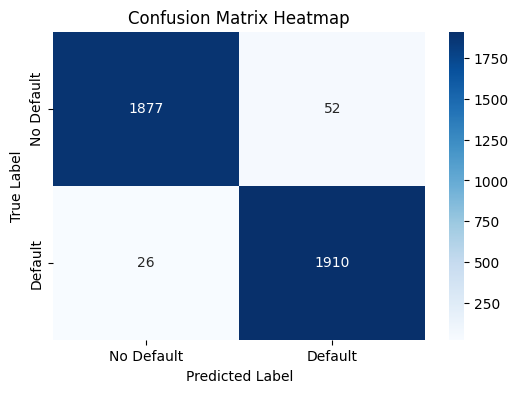

In [107]:
# Plot heatmap
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Saving in Joblib

In [108]:
joblib.dump(pipeline,'Industry.joblib')

['Industry.joblib']

In [109]:
loaded_pipeline=joblib.load('Industry.joblib')

### unseen data prediction

In [110]:
df_unseen=pd.read_csv('unseen_data.csv')
df_unseen

,Air Temperature,Process Temperature,Rotational Speed,Torque,Tool Wear,Toolwear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,Type_H,Type_L,Type_M,Machine failure
0,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,0,1,0
1,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,1,0,0
2,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,1,0,0
3,298.2,308.6,1433.0,39.5,7,0,0,0,0,0,0,1,0,0
4,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,298.9,308.8,1621.0,32.7,75,0,0,0,0,0,1,0,0,0
109,298.9,308.7,1572.0,34.1,80,0,0,0,0,0,0,1,0,0
110,298.8,308.6,1872.0,22.5,82,0,0,0,0,0,0,1,0,0
111,298.7,308.6,1499.0,43.5,84,0,0,0,0,0,1,0,0,0


In [111]:
x_unseen=df_unseen.drop("Machine failure", axis=1)
y_unseen=df_unseen['Machine failure']

In [112]:
y_unseen_pred=loaded_pipeline.predict(x_unseen)

In [113]:
df_unseen['predicted']=y_unseen_pred

In [114]:
unseen_machine = pd.DataFrame([{
    'Type_L': 1,   # Machine type (encoded)
    'Type_M': 0,
    'Type_H': 0,
    'Air temperature [K]': 300.5,
    'Process temperature [K]': 310.1,
    'Rotational speed [rpm]': 1500,
    'Torque [Nm]': 45.5,
    'Tool wear [min]': 120,
    # Failure mode flags (if model trained with them)
    'TWF': 0,
    'HDF': 0,
    'PWF': 0,
    'OSF': 0,
    'RNF': 0
}])

### Inference (based on unseen data results)

The predictive maintenance model was trained using both numeric (sensor readings, tool wear, torque, speed, temperatures) and categorical (machine type/ID, failure types) features.When applied to unseen industrial machine data, the model can be predicted whether a machine is likely to fail.
Predictions can be consistent with expected trends:
- Machines with high tool wear, abnormal temperature differences, or extreme torque/speed will have higher predicted probability of failure.
- Healthy operating conditions corresponds to "no failure" predictions.

### Conclusion

This model building tells the strong potential to accurately identify machines at risk of failure, enabling proactive maintenance strategies and ensuring operational efficiency in manufacturing environments.The model can be integrated into a real-time monitoring system to trigger alerts for maintenance before breakdowns occur.It helps to reduce downtime, maintenance costs, and unexpected machine failures, leading to improved productivity.The system also supports preventive maintenance scheduling by identifying high-risk machines in advance.